# FF Comparison: overlay hFF from multiple files
Plots `hFF_{var}_{q+1}_{x+1}` from several input files on the same axes.
- **fixed_x**: one figure per xB bin, Q² bins overlaid (default)
- **fixed_q**: one figure per Q² bin, xB bins overlaid

Each file gets a distinct color; bins within each file are distinguished by line style.

In [151]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Each entry: (file path, legend label)
FILES = [
    #("../histograms/analysis_note/ratio_3d_no_cut.root", "3D"),
    #("../histograms/analysis_note/ratios_3d.root", "2D"),

    #("../histograms/analysis_note/ratios_2d_k_10.2.root", "10.2"),
    #("../histograms/final_note/ratios_2d_fullUnc.root", "Data"),
    #("../histograms/final_note/ratios_2d_mc_fullUnc.root", "+ MC Correction"),

    #("../histograms/analysis_note/ratio_3d_align.root", "3d aligned"),
    #("../histograms/analysis_note/ratios_2d_k.root", "+ K"),
    #("../histograms/analysis_note/ratios_3d_k.root", "3D"),
    #("../histograms/analysis_note/ratios_gen.root", "Gen"),

    #("../histograms/final_note/ratios_2d_k_fullUnc.root", "+ MisId Correction"),
    #("../histograms/final_note/ratios_2d_rho_pT_no_match_fullUnc.root", r"+ Rho"),
    #("../histograms/final_note/ratios_2d_fullUnc.root", r"Data"),
    #("../histograms/final_note/ratios_2d_mc_fullUnc.root", r"+MC"),
    #("../histograms/final_note/ratios_2d_k_fullUnc.root", r"+K"),
    #("../histograms/final_note/ratios_2d_rho_fullUnc.root", r"+Rho"),


    ("../histograms/final_note/ratios_gen_string.root", r"Gen"),
    ("../histograms/final_note/ratios_gen_cuts.root", r"Gen+Cuts"),
    ("../histograms/final_note/ratios_gen_cuts_no_match.root", r"Gen+Cuts no match"),

    #("../histograms/final_note/ratios_3d_k_fullUnc.root", "3D Acceptance Matching")

    #("../histograms/analysis_note/ratios_10.2_rho_pT_fullUnc.root", r"$\pi^-$ Tagging (ANALYSIS)"),

    #("../histograms/final_note/ratios_2d_k_1_fullUnc.root", r"Threshold = 1%"),
    #("../histograms/final_note/ratios_2d_k_5_fullUnc.root", r"Threshold = 5%"),
    #("../histograms/final_note/ratios_2d_k_15_fullUnc.root", r"Threshold = 15%"),
    #("../histograms/final_note/ratios_2d_k_20_fullUnc.root", r"Threshold = 20%"),
    #("../histograms/final_note/ratios_2d_k_25_fullUnc.root", r"Threshold = 25%"),
    #("../histograms/final_note/ratios_2d_k_50_fullUnc.root", r"Threshold = 50%"),

    #("../histograms/final_note/ratios_2d_rho_10.2_fullUnc.root", r"$E=10.2$"),
    #("../histograms/final_note/ratios_2d_rho_10.4_fullUnc.root", r"$E=10.4$"),
    #("../histograms/final_note/ratios_2d_rho_10.6_fullUnc.root", r"$E=10.6$"),
    #    ("../histograms/analysis_note/ratios_2d_rho.root", r"All $E"),

    #("../histograms/analysis_note/ratios_2d_rho_10.2.root", r"$E=10.2$ [GeV]"),
    #("../histograms/analysis_note/ratios_2d_rho_10.4.root", r"$E=10.4$ [GeV]"),
    #("../histograms/analysis_note/ratios_2d_rho_10.6.root", r"$E=10.6$ [GeV]"),
]

OUT_DIR = None  # e.g. "../plotting/analysis_note/ratio_mc_effect" — None = display inline

# Plot mode
# 'fixed_x' : one figure per xB bin, Q2 bins overlaid as different line styles
# 'fixed_q' : one figure per Q2 bin, xB bins overlaid as different line styles
MODE = 'fixed_x'
ylim = [0, .8]
VAR = 0   # histogram type index (0 for standard hFF/hDuM runs)

# Kinematic bin definitions — must match cut_values.h
BINS_Q2 = 12;  Q2_MIN, Q2_MAX = 2.0, 8.0
BINS_XB = 14;  XB_MIN, XB_MAX = 0.1, 0.66

# Extra binning variable — must match makeGenFFRatio var_name / bins_var args
# Set BINS_VAR > 1 only when files were produced with bins_var > 1.
# VAR_NAME and VAR_MIN/VAR_MAX are used for axis labels only.
BINS_VAR = 1    # 1 = no extra variable (default)
VAR_NAME = "null"   # e.g. "pT", "Mx", "xF"
VAR_MIN  = 0.0
VAR_MAX  = 1.0

In [ ]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def q2_label(q):
    lo = Q2_MIN + q * (Q2_MAX - Q2_MIN) / BINS_Q2
    hi = Q2_MIN + (q + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
    return rf"${lo:.1f} < Q^2 < {hi:.1f}\;\mathrm{{GeV}}^2$"

def xb_label(x):
    lo = XB_MIN + x * (XB_MAX - XB_MIN) / BINS_XB
    hi = XB_MIN + (x + 1) * (XB_MAX - XB_MIN) / BINS_XB
    return rf"${lo:.2f} < x_B < {hi:.2f}$"

def var_label(v):
    lo = VAR_MIN + v * (VAR_MAX - VAR_MIN) / BINS_VAR
    hi = VAR_MIN + (v + 1) * (VAR_MAX - VAR_MIN) / BINS_VAR
    name = VAR_NAME if VAR_NAME != "null" else "var"
    return rf"${lo:.2f} < {name} < {hi:.2f}$"

def load_hFF(f, var, q, x, v=0):
    """Return (centers, vals, errs, mask) for hFF/hDuM_{var}_{q+1}_{x+1}[_v{v+1}], or None."""
    tag = f"_{var}_{q+1}_{x+1}"
    if BINS_VAR > 1:
        tag += f"_v{v+1}"

    # Try hDuM first, then hFF; uproot resolves ;1 cycles automatically
    key = None
    for prefix in ("hDuM", "hFF"):
        candidate = prefix + tag
        if candidate in f or (candidate + ";1") in f:
            key = candidate
            break
    if key is None:
        return None

    try:
        h = f[key]
    except Exception:
        return None

    edges   = h.axis().edges()
    centers = 0.5 * (edges[:-1] + edges[1:])
    vals    = np.array(h.values())
    errs    = np.array(h.errors())
    mask    = np.isfinite(vals) & (vals != 0)
    if not mask.any():
        return None
    return centers, vals, errs, mask

Loaded: ../histograms/final_note/ratios_gen_string.root
Loaded: ../histograms/final_note/ratios_gen_cuts.root
Loaded: ../histograms/final_note/ratios_gen_cuts_no_match.root


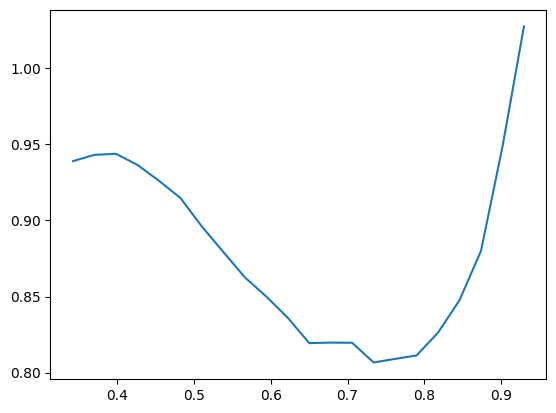

In [154]:
# ── Load files ─────────────────────────────────────────────────────────────────
opened = []
for fpath, flabel in FILES:
    try:
        opened.append((uproot.open(fpath), flabel))
        print(f"Loaded: {fpath}")
    except Exception as e:
        print(f"WARNING: could not open {fpath}: {e}")

import numpy as np

# z values
z = np.array([0.342, 0.370, 0.398, 0.426, 0.454, 0.482, 0.510, 0.538,
              0.566, 0.594, 0.622, 0.650, 0.678, 0.706, 0.734, 0.762,
              0.790, 0.818, 0.846, 0.874, 0.902, 0.930])

# D-/D+ after rho subtraction
ratio_after = np.array([0.4620, 0.4196, 0.4838, 0.4764, 0.4575, 0.4425, 0.4059, 0.3635,
                        0.3699, 0.3638, 0.3448, 0.3157, 0.3587, 0.3934, 0.3137, 0.3164,
                        0.2738, 0.2625, 0.2380, 0.2294, 0.2423, 0.3025])
ratio_after_err = np.array([0.0710, 0.0475, 0.0453, 0.0429, 0.0414, 0.0413, 0.0318, 0.0270,
                            0.0266, 0.0274, 0.0298, 0.0289, 0.0314, 0.0327, 0.0273, 0.0254,
                            0.0223, 0.0198, 0.0177, 0.0161, 0.0243, 0.0739])

# D-/D+ before rho subtraction
ratio_before = np.array([0.4920, 0.4449, 0.5126, 0.5087, 0.4940, 0.4837, 0.4530, 0.4134,
                         0.4288, 0.4280, 0.4124, 0.3853, 0.4376, 0.4800, 0.3889, 0.3911,
                         0.3375, 0.3177, 0.2808, 0.2607, 0.2555, 0.2944])
ratio_before_err = np.array([0.0700, 0.0465, 0.0438, 0.0411, 0.0392, 0.0395, 0.0306, 0.0257,
                             0.0253, 0.0267, 0.0284, 0.0279, 0.0307, 0.0319, 0.0264, 0.0254,
                             0.0223, 0.0198, 0.0168, 0.0159, 0.0238, 0.0724])

plt.plot(z, ratio_after/ratio_before)

In [ ]:
from IPython.display import display

# ── Plot ───────────────────────────────────────────────────────────────────────
if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

file_colors  = ["#e8184c",'#3cb44b','#4363d8','#f58231','#911eb4',
                '#42d4f4','#f032e6','#bfef45','#469990','#dcbeff']
file_markers = ['o','s','^','D','v','<','>','p','h','P']
bin_linestyles = ['-', '--', ':', '-.', (0,(3,1,1,1)), (0,(5,1)), (0,(1,1))]

def ff_theory(z):
    return (1 - z) / (z + 1)

z_ref = np.linspace(0.3, 0.85, 300)

# Determine outer/inner loop axes based on MODE
if MODE == 'fixed_x':
    outer_range    = range(BINS_XB)
    inner_range    = range(BINS_Q2)
    outer_label_fn = xb_label
    inner_label_fn = q2_label
    outer_key      = 'x'
else:  # fixed_q
    outer_range    = range(BINS_Q2)
    inner_range    = range(BINS_XB)
    outer_label_fn = q2_label
    inner_label_fn = xb_label
    outer_key      = 'q'

for v in range(BINS_VAR):
    for oi in outer_range:

        fig, (ax_ff, ax_rat) = plt.subplots(
            2, 1, figsize=(11, 7),
            gridspec_kw={'height_ratios': [3, 1]},
            sharex=True
        )
        fig.tight_layout(pad=2.0)

        ax_ff.plot(z_ref, ff_theory(z_ref), color='black', ls='--', lw=1.2,
                   label='$(1-z)/(1+z)$', zorder=0)
        ax_rat.axhline(1, color='black', ls='--', lw=1, zorder=0)

        has_data = False

        for ii in inner_range:
            q, x = (ii, oi) if MODE == 'fixed_x' else (oi, ii)
            ls = bin_linestyles[ii % len(bin_linestyles)]
            ref_vals = None

            for fi, (fobj, flabel) in enumerate(opened):
                result = load_hFF(fobj, VAR, q, x, v)
                if result is None:
                    continue
                centers, vals, errs, mask = result
                color  = file_colors[fi % len(file_colors)]
                marker = file_markers[fi % len(file_markers)]

                # Legend: file colors shown on first inner bin; bin linestyles shown for first file on later bins
                if ii == 0:
                    ff_lbl = flabel
                elif fi == 0:
                    ff_lbl = inner_label_fn(ii)
                else:
                    ff_lbl = None

                ax_ff.errorbar(
                    centers[mask], vals[mask], errs[mask],
                    marker=marker, color=color, ls=ls,
                    capsize=2, lw=1, capthick=1, markersize=4, mec='black',
                    label=ff_lbl
                )
                has_data = True

                if fi == 0:
                    ref_vals = vals.copy()
                elif ref_vals is not None:
                    ref_mask = mask & (ref_vals != 0)
                    ratio = np.where(ref_mask, vals / ref_vals, np.nan)
                    ratio_err = np.where(
                        ref_mask,
                        errs / np.where(ref_vals > 0, ref_vals, 1),
                        np.nan
                    )
                    rat_lbl = f"{flabel}/{opened[0][1]}" if ii == 0 else None
                    ax_rat.errorbar(
                        centers[ref_mask], ratio[ref_mask], ratio_err[ref_mask],
                        marker=marker, color=color, ls=ls,
                        capsize=2, lw=1, capthick=1, markersize=4, mec='black',
                        label=rat_lbl
                    )

        if not has_data:
            plt.close(fig)
            continue

        title = outer_label_fn(oi)
        if BINS_VAR > 1:
            title += f",  {var_label(v)}"

        ax_ff.text(0.03, 0.97, title, transform=ax_ff.transAxes,
                   fontsize=11, va='top', ha='left',
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
        ax_ff.set_ylabel(r'$FF(z) = (4-R)/(4R-1)$', fontsize=12)
        ax_ff.set_xlim(0.3, .85)
        ax_ff.set_ylim([.2, .7])
        ax_ff.tick_params(labelsize=11)
        ax_ff.legend(fontsize=9, loc='upper right')

        ax_rat.set_xlabel(r'$z$', fontsize=13)
        ax_rat.set_ylabel('Ratio', fontsize=11)
        ax_rat.set_ylim(0.75, 1.25)
        ax_rat.tick_params(labelsize=11)
        if len(opened) > 1:
            ax_rat.legend(fontsize=9, loc='upper right')

        plt.subplots_adjust(hspace=0.05)

        if OUT_DIR:
            vstr  = f"_v{v+1}" if BINS_VAR > 1 else ""
            fname = f"{OUT_DIR}/{outer_key}{oi+1}{vstr}.png"
            fig.savefig(fname, dpi=150)
            plt.close(fig)
            print(f"Saved {fname}")
        else:
            display(fig)
            plt.close(fig)